# Boosting (EDA-4)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import joblib

## Import data

In [11]:
# Reading data
X_train = pd.read_csv('../data/processed/X_train_eda4_obj1.csv')
X_test = pd.read_csv('../data/processed/X_test_eda4_obj1.csv')
y_train = pd.read_csv('../data/processed/y_train_eda4_obj1.csv')
y_test = pd.read_csv('../data/processed/y_test_eda4_obj1.csv')

In [19]:
X_train.columns

Index(['Close', 'Volume', 'Ticker', 'EMA_12', 'MACD', 'MACD_Signal', 'RSI',
       'BB_Upper', 'BB_Lower', 'BB_Position', 'Volatility', 'Price_Change',
       'Volume_Ratio', 'Volume_lag_1', 'Volume_lag_2', 'Volume_lag_3',
       'Volume_lag_5', 'Volume_lag_10', 'RSI_lag_1', 'MACD_lag_1',
       'Volatility_lag_1', 'retorno_5d', 'volatilidad_10d', 'MACD_Bullish',
       'RSI_Trend_Up', 'BB_Breakout', 'High_Volume_Signal'],
      dtype='object')

## Creating model and training data - XGBoost

In [12]:
# Initialize XGBoost model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42, n_jobs=-1)

# Train the model
xgb_model.fit(X_train, y_train.values.ravel())

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Predictions

In [13]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

In [14]:
# Evaluate accuracy and other metrics
model_accuracy = accuracy_score(y_test, y_pred)
model_precision = precision_score(y_test, y_pred)
model_recall = recall_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred)
model_roc_auc = roc_auc_score(y_test, y_proba)
model_cm = confusion_matrix(y_test, y_pred)
model_report = classification_report(y_test, y_pred)

In [15]:
# Showing results
model_accuracy, model_precision, model_recall, model_f1, model_roc_auc

(0.5203810548275637,
 0.5210515281613753,
 0.9005734631502662,
 0.6601532500678481,
 0.5205177232881734)

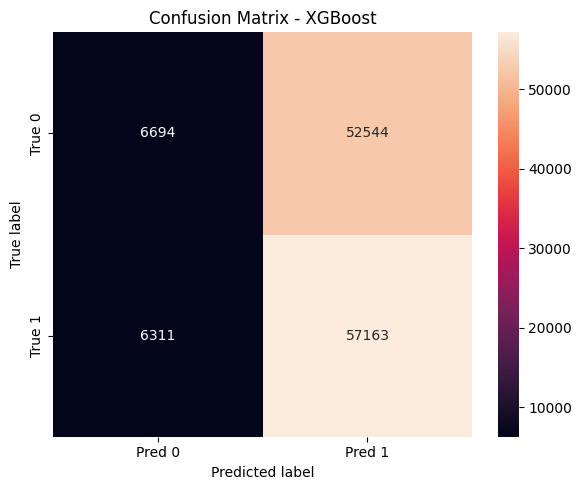

In [16]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(model_cm, annot=True, fmt="d", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])

plt.title("Confusion Matrix - XGBoost")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [17]:
# Classification report
classification_report(y_test, y_pred, digits=3)

'              precision    recall  f1-score   support\n\n           0      0.515     0.113     0.185     59238\n           1      0.521     0.901     0.660     63474\n\n    accuracy                          0.520    122712\n   macro avg      0.518     0.507     0.423    122712\nweighted avg      0.518     0.520     0.431    122712\n'

## Optimization

In [ ]:
# Hyperparameters to test
hyperparams = {"n_estimators" : [100, 200],
               "learning_rate" : [0.05, 0.1],
               "max_depth" : [2, 3, 4],
               "min_split_loss" : [0, 0.1],
               "subsample" : [0.7, 0.8],
               "colsample_bytree" : [0.7, 0.8]}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search = GridSearchCV(xgb_model, hyperparams, scoring="roc_auc", cv=tscv, n_jobs=-1)
grid_search.fit(X_train, y_train.values.ravel())

In [ ]:
# Best parameters and evaluation
grid_model_xgb = grid_search.best_estimator_

y_pred_opt = grid_model_xgb.predict(X_test)
y_proba_opt = grid_model_xgb.predict_proba(X_test)[:,1]

In [ ]:
# Metrics for optimized model
test_accuracy = accuracy_score(y_test, y_pred_opt)
test_precision = precision_score(y_test, y_pred_opt)
test_recall = recall_score(y_test, y_pred_opt)
test_f1 = f1_score(y_test, y_pred_opt)
test_roc_auc = roc_auc_score(y_test, y_proba_opt)

In [ ]:
# Showing results
test_accuracy, test_precision, test_recall, test_f1, test_roc_auc

(0.5180479446518921,
 0.5267013232514177,
 0.7908156969210834,
 0.6322858340938803,
 0.5062516580546943)

## Creating model and training data - Gradient Boosting

In [ ]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=42)

# Train the model
gb_model.fit(X_train, y_train.values.ravel())

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Predictions

In [ ]:
# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

In [ ]:
# Evaluate accuracy and other metrics
model_accuracy_gb = accuracy_score(y_test, y_pred_gb)
model_precision_gb = precision_score(y_test, y_pred_gb)
model_recall_gb = recall_score(y_test, y_pred_gb)
model_f1_gb = f1_score(y_test, y_pred_gb)
model_roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)

In [ ]:
# Showing results
model_accuracy_gb, model_precision_gb, model_recall_gb, model_f1_gb, model_roc_auc_gb

(0.5184520634304834,
 0.5263142060610922,
 0.8095730240019745,
 0.6379128024989973,
 0.5050863461488471)

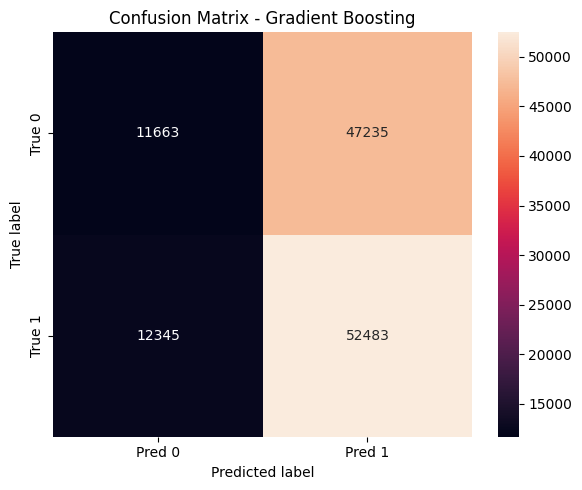

In [ ]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt="d", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])

plt.title("Confusion Matrix - Gradient Boosting")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [ ]:
# Classification report
classification_report(y_test, y_pred_gb, digits=3)

'              precision    recall  f1-score   support\n\n           0      0.486     0.198     0.281     58898\n           1      0.526     0.810     0.638     64828\n\n    accuracy                          0.518    123726\n   macro avg      0.506     0.504     0.460    123726\nweighted avg      0.507     0.518     0.468    123726\n'

## Optimization

In [ ]:
# Hyperparameters to test
hyperparams_gb = {"n_estimators" : [100, 200],
                  "learning_rate" : [0.05, 0.1],
                  "max_depth" : [2, 3, 4],
                  "subsample" : [0.7, 0.8],
                  "max_features" : ["sqrt", "log2"]}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search_gb = GridSearchCV(gb_model, hyperparams_gb, scoring="roc_auc", cv=tscv, n_jobs=-1)
grid_search_gb.fit(X_train, y_train.values.ravel())

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [ ]:
# Best parameters and evaluation
grid_model_gb = grid_search_gb.best_estimator_

y_pred_gb_opt = grid_model_gb.predict(X_test)
y_proba_gb_opt = grid_model_gb.predict_proba(X_test)[:,1]

In [ ]:
# Metrics for optimized model
test_accuracy_gb = accuracy_score(y_test, y_pred_gb_opt)
test_precision_gb = precision_score(y_test, y_pred_gb_opt)
test_recall_gb = recall_score(y_test, y_pred_gb_opt)
test_f1_gb = f1_score(y_test, y_pred_gb_opt)
test_roc_auc_gb = roc_auc_score(y_test, y_proba_gb_opt)

In [ ]:
# Showing results
test_accuracy_gb, test_precision_gb, test_recall_gb, test_f1_gb, test_roc_auc_gb

(0.5177893086335936,
 0.5270539193095647,
 0.7762232368729561,
 0.6278196426789101,
 0.5064995770207759)

In [18]:
# Saving best model
joblib.dump(xgb_model, "../models/xgb-model-eda4.pkl")

['../models/xgb-model-eda4.pkl']

### Conclusión

### Conclusion